# Seasonal Agriculture Performance 

**Dataset:** seasonal_agriculture_performance_dataset.csv
**Goal:** Understand how season, crop choice, irrigation and input use are tied to yield and profit across farms and pull out patterns that could actually be useful for someone making planting or investment decisions.

 I am going in mostly blind on this one - no prior domain notes were given, so a chunk of this notebook is just me getting familiar with the columns before I try to answer anything.

Rough plan for this notebook:
1. Load the data and get a feel for it
2. Clean up - missing values, duplicates, obvious data issues
3. Descriptive stats + outlier check
4. Univariate -> Bivariate -> Multivariate analysis
5. Correlation + seasonal comparison
6. A few analyses I designed myself
7. Insights, recommendations, limitations, conclusion


## 1. Loading the dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# just some display/plot settings so things don't look cramped
pd.set_option('display.max_columns', 40)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (9, 5)


In [2]:
df = pd.read_csv('seasonal_agriculture_performance_dataset.csv')
print('Loaded fine. Shape:', df.shape)


Loaded fine. Shape: (4000, 28)


### 1.1 First look at the rows

Just checking the data actually loaded the way I expect and the columns look sane.

In [3]:
df.head()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,7.14,32.8,75.8,61.3,91.0,Drip,242.7,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,5.20,32.0,82.1,35.4,121.8,Flood,271.4,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,5.82,8.1,118.5,51.5,117.9,Drip,162.6,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,5.98,23.7,138.6,55.6,115.5,Rainfed,182.2,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,6.90,29.3,124.1,69.0,121.4,Flood,244.9,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [4]:
df.sample(5, random_state=1)  # a random sample too, head() alone can be misleading

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
200,SF10201,Punjab,Ludhiana,Wheat,Rabi,5.61,227.1,22.6,77.0,8.4,6.19,30.3,148.9,56.1,91.2,Rainfed,213.6,7.57,0.98,1.44,8.08,20443,386380,165179,-221201,1481,5.456,19.7
1078,SF11079,Madhya Pradesh,Nalgonda,Pulses,Rabi,10.56,611.7,21.3,57.9,9.1,7.68,30.6,111.2,65.4,119.2,Drip,220.3,2.94,0.98,0.37,3.91,65161,654685,254780,-399905,3540,1.105,50.8
610,SF10611,Karnataka,Erode,Wheat,Kharif,5.51,972.1,25.4,82.9,7.1,6.64,35.1,121.0,58.9,75.0,Flood,97.1,5.17,0.90,2.66,14.66,20341,331994,298199,-33795,3594,4.079,47.0
2159,SF12160,Gujarat,Guntur,Cotton,Kharif,6.09,1095.9,26.0,79.8,6.6,5.94,33.8,86.7,78.1,104.5,Drip,267.8,8.54,0.89,0.75,4.57,65235,449847,298124,-151723,3796,1.204,38.6
1169,SF11170,Andhra Pradesh,Erode,Pulses,Kharif,12.03,789.5,28.3,72.3,6.4,6.83,33.6,120.7,28.4,113.3,Flood,187.6,5.85,1.00,1.57,18.89,61727,809336,1166023,356687,5270,3.584,45.9


## 2. Shape, structure and data types

In [5]:
print('Rows:', df.shape[0])
print('Columns:', df.shape[1])


Rows: 4000
Columns: 28


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   str    
 1   State                          4000 non-null   str    
 2   District                       4000 non-null   str    
 3   Crop                           4000 non-null   str    
 4   Season                         4000 non-null   str    
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   float64
 13 

Notes so far:
- 4000 rows, 28 columns.
- `Farm_ID` is a plain string ID, not useful for any calculation -  I will leave it as an identifier only.
- `State`, `District`, `Crop`, `Season`, `Irrigation_Method` are categorical/text columns.
- Everything else is numeric (either float or int), which makes sense - rainfall, temperature, cost, yield etc.
- A few columns (`Rainfall_mm`, `Soil_Moisture_pct`, `Yield_Tonnes_Ha`) show fewer non-null rows than 4000 in the info() output above, so there's missing data to deal with in the next section.

In [7]:
df.dtypes.value_counts()


float64    17
str         6
int64       5
Name: count, dtype: int64

In [8]:
# quick check on the categorical columns - what values do we actually have?
for col in ['State', 'Crop', 'Season', 'Irrigation_Method']:
    print(col, '->', df[col].nunique(), 'unique values')
    print(sorted(df[col].unique()))
    print()


State -> 8 unique values
['Andhra Pradesh', 'Gujarat', 'Karnataka', 'Madhya Pradesh', 'Maharashtra', 'Punjab', 'Tamil Nadu', 'Telangana']

Crop -> 8 unique values
['Chilli', 'Cotton', 'Groundnut', 'Maize', 'Pulses', 'Rice', 'Sugarcane', 'Wheat']

Season -> 3 unique values
['Kharif', 'Rabi', 'Zaid']

Irrigation_Method -> 4 unique values
['Drip', 'Flood', 'Rainfed', 'Sprinkler']



8 states, 8 crops, 3 seasons (Kharif, Rabi, Zaid) and 4 irrigation methods. Nothing weird jumping out - no stray whitespace or inconsistent casing that I can see, which is nice for once.

## 3. Missing values

In [9]:
missing = df.isnull().sum()
missing = missing[missing > 0]
missing_pct = (missing / len(df) * 100).round(2)
pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})


,missing_count,missing_pct
Rainfall_mm,48,1.2
Soil_Moisture_pct,40,1.0
Yield_Tonnes_Ha,32,0.8


So three columns have gaps:
- `Rainfall_mm` - 48 missing (1.2%)
- `Soil_Moisture_pct` - 40 missing (1.0%)
- `Yield_Tonnes_Ha` - 32 missing (0.8%)

All three are small percentages, so  I am not going to drop any rows over this - that would just throw away otherwise good data. I also don't want to fill everything with one global median, because rainfall and yield both depend a lot on crop and season (sugarcane yield is nowhere near chilli yield, monsoon-season rainfall is nowhere near summer rainfall). So  I will fill using group-wise medians instead of one flat number.

In [10]:
# Yield depends heavily on crop -> fill missing yield with the median yield for that crop
df['Yield_Tonnes_Ha'] = df.groupby('Crop')['Yield_Tonnes_Ha'].transform(lambda x: x.fillna(x.median()))

# Rainfall depends on season -> fill missing rainfall with median rainfall for that season
df['Rainfall_mm'] = df.groupby('Season')['Rainfall_mm'].transform(lambda x: x.fillna(x.median()))

# Soil moisture doesn't have as obvious a grouping, so a straightforward overall median is fine here
df['Soil_Moisture_pct'] = df['Soil_Moisture_pct'].fillna(df['Soil_Moisture_pct'].median())

print('Missing values left:', df.isnull().sum().sum())


Missing values left: 0


Good, all cleared. Double-checking nothing sneaky is hiding as an empty string instead of a real NaN:

In [11]:
for col in df.select_dtypes(include='object').columns:
    blanks = (df[col].astype(str).str.strip() == '').sum()
    if blanks:
        print(col, blanks)
print('done checking - no blank strings found' )


done checking - no blank strings found


/tmp/ipykernel_475/2168046548.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include='object').columns:


## 4. Duplicate records

In [12]:
print('Fully duplicated rows:', df.duplicated().sum())
print('Duplicated Farm_ID values:', df['Farm_ID'].duplicated().sum())


Fully duplicated rows: 0
Duplicated Farm_ID values: 0


No duplicate rows and no repeated Farm IDs, so there's nothing to remove here. Good sign - means each row really is one distinct farm record. (Still glad I checked instead of assuming.)

## 5. Descriptive / statistical summary

In [13]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Farm_Area_Hectares,4000.0,7.888265,4.223764,0.500,4.260,7.8950,11.65000,15.00
Rainfall_mm,4000.0,600.714313,288.427366,80.000,370.425,581.0000,836.12500,1395.20
Avg_Temperature_C,4000.0,26.818900,3.818180,16.200,23.900,26.9000,29.60000,39.70
Humidity_pct,4000.0,63.210500,11.960834,25.000,54.775,63.0000,71.90000,95.00
Sunlight_Hours_Day,4000.0,7.323050,1.121186,3.500,6.600,7.3000,8.10000,11.00
Soil_pH,4000.0,6.701010,0.641461,5.200,6.260,6.6900,7.14000,8.40
Soil_Moisture_pct,4000.0,26.507150,6.678837,8.000,21.800,26.4000,31.20000,47.00
Nitrogen_kg_ha,4000.0,120.250825,31.216452,40.000,98.500,120.1000,141.22500,220.00
Phosphorus_kg_ha,4000.0,57.781850,17.015074,15.000,46.200,57.5000,69.40000,120.00
Potassium_kg_ha,4000.0,104.760050,27.742681,30.000,86.200,105.1000,123.60000,200.00


A few things stand out just from this table:

- `Yield_Tonnes_Ha` has a mean of ~5.3 but a median of only 1.74 - that gap between mean and median is a strong sign of a right-skewed distribution with some big values pulling the average up (checked below in the outliers section and it turns out to be sugarcane, which genuinely yields way more per hectare than the other crops).
- `Profit_INR` has a minimum of about -1,019,223 and a max of about 4,345,421 - so there are farms making a solid profit and farms taking a heavy loss, sitting right next to each other in the same dataset.
- `Farm_Area_Hectares` tops out at 15, so this looks like it's built around small/marginal farms rather than big commercial operations.
- Some columns like `Seed_Quality_Score` are scored 0-1, so they're on a totally different scale to something like `Total_Cost_INR` which is in the hundreds of thousands - worth remembering before comparing columns directly later.


In [14]:
# separating out numeric columns for later use - saves retyping this list everywhere
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(len(num_cols), 'numeric columns')
num_cols


22 numeric columns


['Farm_Area_Hectares',
 'Rainfall_mm',
 'Avg_Temperature_C',
 'Humidity_pct',
 'Sunlight_Hours_Day',
 'Soil_pH',
 'Soil_Moisture_pct',
 'Nitrogen_kg_ha',
 'Phosphorus_kg_ha',
 'Potassium_kg_ha',
 'Fertilizer_kg_ha',
 'Pesticide_Litre_ha',
 'Seed_Quality_Score',
 'Yield_Tonnes_Ha',
 'Production_Tonnes',
 'Market_Price_INR_Tonne',
 'Total_Cost_INR',
 'Revenue_INR',
 'Profit_INR',
 'Water_Used_m3',
 'Water_Efficiency_t_per_1000m3',
 'Disease_Pest_Risk_pct']

In [15]:
# rounding just for a cleaner read on spread (std) per column
df[num_cols].std().sort_values(ascending=False).round(2)


Revenue_INR                      636974.71
Profit_INR                       545081.89
Total_Cost_INR                   294419.14
Market_Price_INR_Tonne            30266.16
Water_Used_m3                      5572.94
Rainfall_mm                         288.43
Production_Tonnes                   126.88
Fertilizer_kg_ha                     60.26
Nitrogen_kg_ha                       31.22
Potassium_kg_ha                      27.74
Phosphorus_kg_ha                     17.02
Yield_Tonnes_Ha                      13.35
Disease_Pest_Risk_pct                12.42
Humidity_pct                         11.96
Water_Efficiency_t_per_1000m3         8.84
Soil_Moisture_pct                     6.68
Farm_Area_Hectares                    4.22
Avg_Temperature_C                     3.82
Pesticide_Litre_ha                    1.98
Sunlight_Hours_Day                    1.12
Soil_pH                               0.64
Seed_Quality_Score                    0.10
dtype: float64

## 6. Outliers

`Yield_Tonnes_Ha` and `Profit_INR` both looked skewed above, so let's actually look at them with boxplots instead of guessing from numbers.

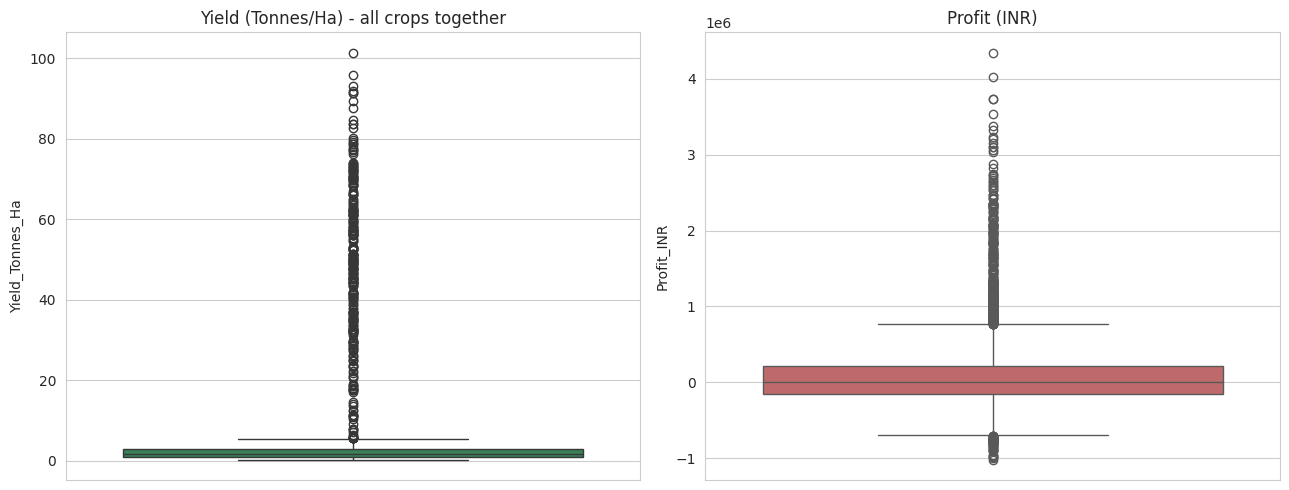

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.boxplot(y=df['Yield_Tonnes_Ha'], ax=axes[0], color='seagreen')
axes[0].set_title('Yield (Tonnes/Ha) - all crops together')
sns.boxplot(y=df['Profit_INR'], ax=axes[1], color='indianred')
axes[1].set_title('Profit (INR)')
plt.tight_layout()
plt.show()


In [17]:
# IQR based outlier count, done the standard way, on the whole column
def iqr_outlier_count(series):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return ((series < lower) | (series > upper)).sum(), lower, upper

for col in ['Yield_Tonnes_Ha', 'Profit_INR', 'Water_Efficiency_t_per_1000m3']:
    cnt, low, up = iqr_outlier_count(df[col])
    print(f'{col}: {cnt} flagged outliers (bounds: {low:.2f} to {up:.2f})')


Yield_Tonnes_Ha: 304 flagged outliers (bounds: -1.63 to 5.52)
Profit_INR: 404 flagged outliers (bounds: -696111.00 to 763567.00)
Water_Efficiency_t_per_1000m3: 322 flagged outliers (bounds: -3.57 to 10.38)


302 farms get flagged as yield outliers when I treat the whole column as one group. But that's misleading here - before assuming these are bad data points, I checked which crop they belong to:

In [18]:
top_yield = df.sort_values('Yield_Tonnes_Ha', ascending=False).head(15)
top_yield[['Farm_ID', 'Crop', 'Season', 'Yield_Tonnes_Ha']]


,Farm_ID,Crop,Season,Yield_Tonnes_Ha
1715,SF11716,Sugarcane,Kharif,101.44
3423,SF13424,Sugarcane,Kharif,95.79
3525,SF13526,Sugarcane,Rabi,93.13
1464,SF11465,Sugarcane,Kharif,91.98
3523,SF13524,Sugarcane,Kharif,91.46
2782,SF12783,Sugarcane,Rabi,91.32
644,SF10645,Sugarcane,Kharif,89.34
2847,SF12848,Sugarcane,Kharif,87.76
357,SF10358,Sugarcane,Rabi,84.75
1178,SF11179,Sugarcane,Kharif,83.79


In [19]:
df.groupby('Crop')['Yield_Tonnes_Ha'].describe()[['count','mean','min','max']]


,count,mean,min,max
Crop,,,,
Chilli,412.0,1.540583,0.30,3.90
Cotton,508.0,1.225846,0.30,2.90
Groundnut,424.0,1.318892,0.30,3.02
Maize,551.0,2.718094,0.30,6.08
Pulses,496.0,0.918286,0.30,2.09
Rice,690.0,2.439652,0.30,5.70
Sugarcane,305.0,46.945902,1.39,101.44
Wheat,614.0,2.109593,0.30,4.56


That explains it - every single one of the top "outlier" values is Sugarcane and Sugarcane's yield is naturally in a completely different range (medians of ~48 t/ha vs under 3 t/ha for everything else). Sugarcane is just a bulkier crop by weight, so this isn't bad data - it's the IQR method being applied across mixed crop types when it really should be checked crop by crop. So I did that instead:

In [20]:
outlier_summary = []
for crop, group in df.groupby('Crop'):
    cnt, low, up = iqr_outlier_count(group['Yield_Tonnes_Ha'])
    outlier_summary.append((crop, len(group), cnt))

pd.DataFrame(outlier_summary, columns=['Crop', 'n_records', 'outliers_within_crop']).sort_values('outliers_within_crop', ascending=False)


,Crop,n_records,outliers_within_crop
0,Chilli,412,1
1,Cotton,508,1
2,Groundnut,424,0
3,Maize,551,0
4,Pulses,496,0
5,Rice,690,0
6,Sugarcane,305,0
7,Wheat,614,0


Checked crop by crop, the real outlier count drops a lot (down to a small handful per crop instead of 302 lumped together). Those remaining few are kept as is - they're plausible extreme yields, not something I'd feel right just deleting.

`Profit_INR` is a different story - the spread there is real and it's the whole point of the analysis, so no outlier removal there either. A farm running a big loss isn't a data error, it's exactly the kind of thing this analysis is meant to catch. So overall: no rows get dropped for being "outliers" in this notebook, but the reasoning behind that decision matters more than the check itself.

## 7. Univariate analysis

Looking at single columns on their own first, before mixing variables together.

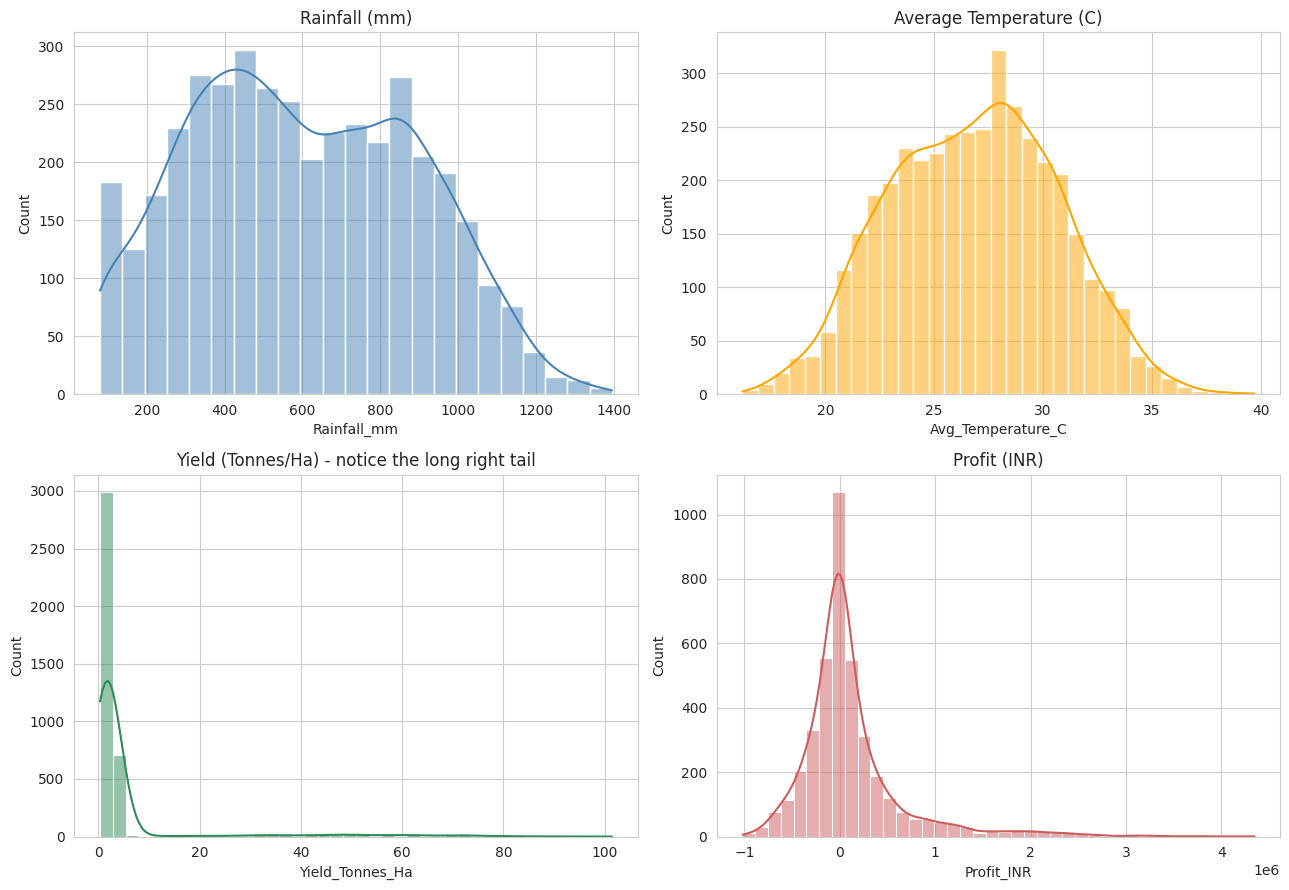

In [21]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

sns.histplot(df['Rainfall_mm'], kde=True, ax=axes[0,0], color='steelblue')
axes[0,0].set_title('Rainfall (mm)')

sns.histplot(df['Avg_Temperature_C'], kde=True, ax=axes[0,1], color='orange')
axes[0,1].set_title('Average Temperature (C)')

sns.histplot(df['Yield_Tonnes_Ha'], kde=True, ax=axes[1,0], color='seagreen', bins=40)
axes[1,0].set_title('Yield (Tonnes/Ha) - notice the long right tail')

sns.histplot(df['Profit_INR'], kde=True, ax=axes[1,1], color='indianred', bins=40)
axes[1,1].set_title('Profit (INR)')

plt.tight_layout()
plt.show()


Rainfall and temperature both look roughly bell shaped, nothing dramatic. Yield is heavily right-skewed for the reason covered above (sugarcane). Profit is close to a normal-ish shape but centred slightly above zero, with a long tail on the loss side too.

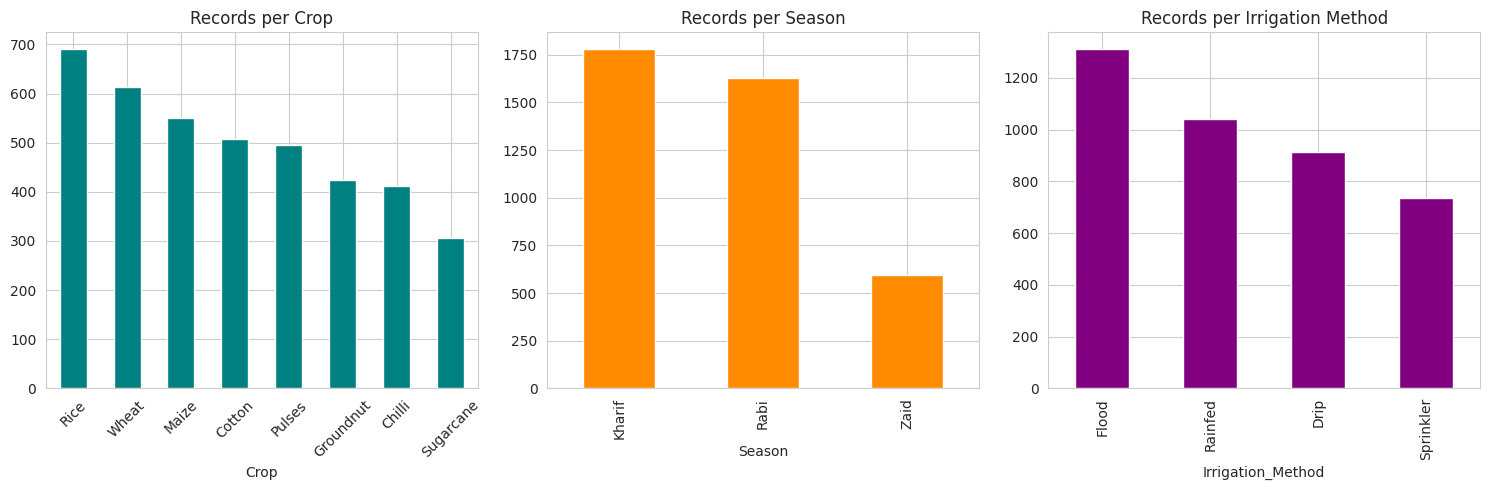

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

df['Crop'].value_counts().plot(kind='bar', ax=axes[0], color='teal')
axes[0].set_title('Records per Crop')
axes[0].tick_params(axis='x', rotation=45)

df['Season'].value_counts().plot(kind='bar', ax=axes[1], color='darkorange')
axes[1].set_title('Records per Season')

df['Irrigation_Method'].value_counts().plot(kind='bar', ax=axes[2], color='purple')
axes[2].set_title('Records per Irrigation Method')

plt.tight_layout()
plt.show()


Crop counts are fairly even (roughly 300-700 records each, so no crop is so rare that comparisons become meaningless). Kharif has the most records, Zaid the fewest - makes sense since Zaid is the short summer season and fewer farms plant in it at all. Irrigation methods are also reasonably balanced across the four types.

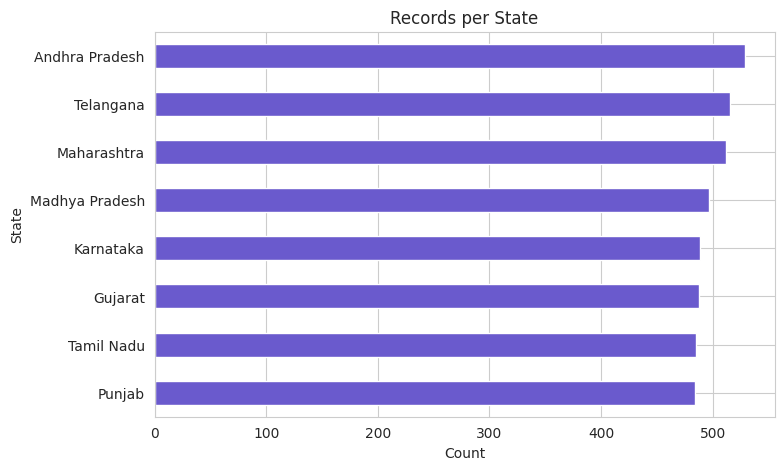

In [23]:
df['State'].value_counts().plot(kind='barh', color='slateblue', figsize=(8,5))
plt.title('Records per State')
plt.xlabel('Count')
plt.gca().invert_yaxis()
plt.show()


## 8. Bivariate analysis

Now pairing up two variables at a time to see if anything moves together.

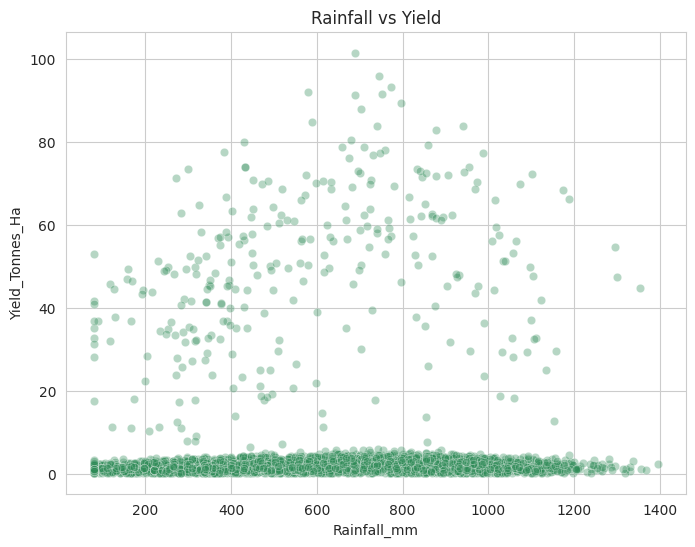

In [24]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x='Rainfall_mm', y='Yield_Tonnes_Ha', alpha=0.35, color='seagreen')
plt.title('Rainfall vs Yield')
plt.show()


Honestly this is close to a flat cloud of points - rainfall on its own doesn't seem to explain yield much, at least not without splitting by crop (checked properly in the correlation section below).

/tmp/ipykernel_475/442143899.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Season', y='Profit_INR', palette='Set2')


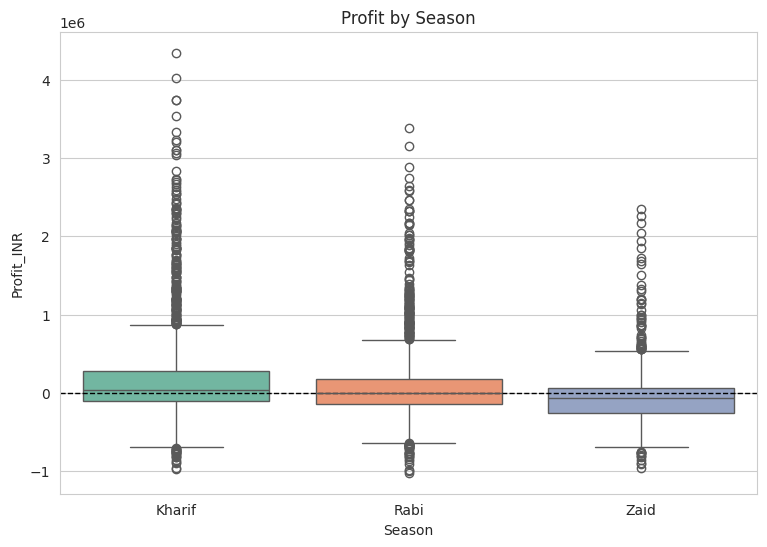

In [25]:
plt.figure(figsize=(9,6))
sns.boxplot(data=df, x='Season', y='Profit_INR', palette='Set2')
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.title('Profit by Season')
plt.show()


Kharif looks like the strongest season for profit on average and Zaid's box sits mostly around/below the zero line, which lines up with what the group means showed earlier.

/tmp/ipykernel_475/561631732.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Irrigation_Method', y='Water_Efficiency_t_per_1000m3', palette='Set3')


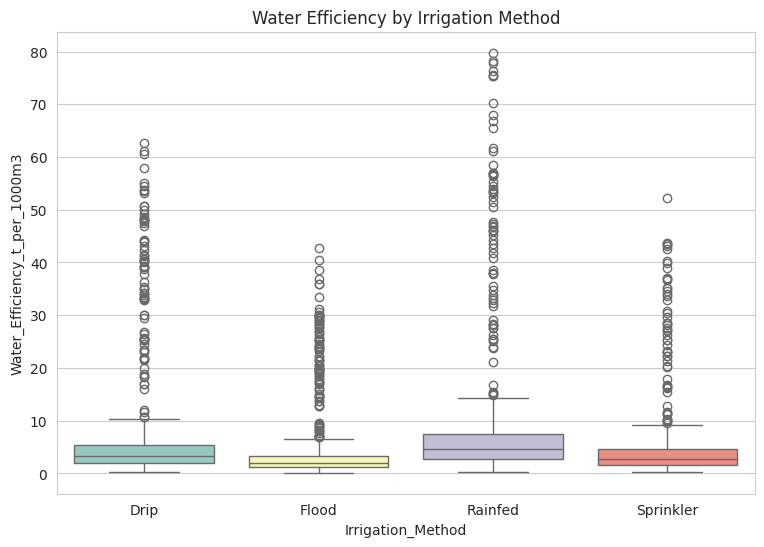

In [26]:
plt.figure(figsize=(9,6))
sns.boxplot(data=df, x='Irrigation_Method', y='Water_Efficiency_t_per_1000m3', palette='Set3')
plt.title('Water Efficiency by Irrigation Method')
plt.show()


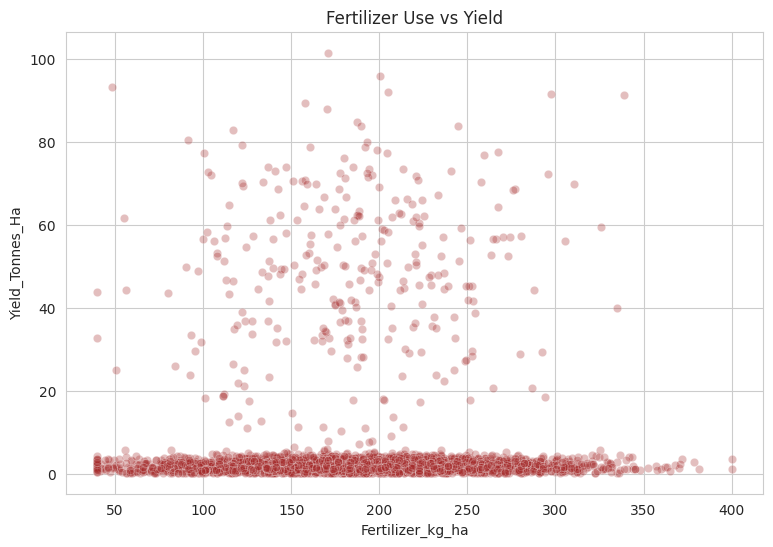

In [27]:
plt.figure(figsize=(9,6))
sns.scatterplot(data=df, x='Fertilizer_kg_ha', y='Yield_Tonnes_Ha', alpha=0.3, color='brown')
plt.title('Fertilizer Use vs Yield')
plt.show()


This one surprised me a bit - I expected more fertilizer to at least loosely track with higher yield, but the scatter is basically flat/noisy. Checked the actual correlation number below to make sure I wasn't misreading the plot.

In [28]:
print('Correlation between Fertilizer_kg_ha and Yield_Tonnes_Ha:', round(df['Fertilizer_kg_ha'].corr(df['Yield_Tonnes_Ha']), 3))


Correlation between Fertilizer_kg_ha and Yield_Tonnes_Ha: -0.0


Yep, basically zero. More on this in the insights section - it's one of the more interesting non-findings in this dataset.

## 9. Multivariate analysis

Bringing in three or more variables at once.

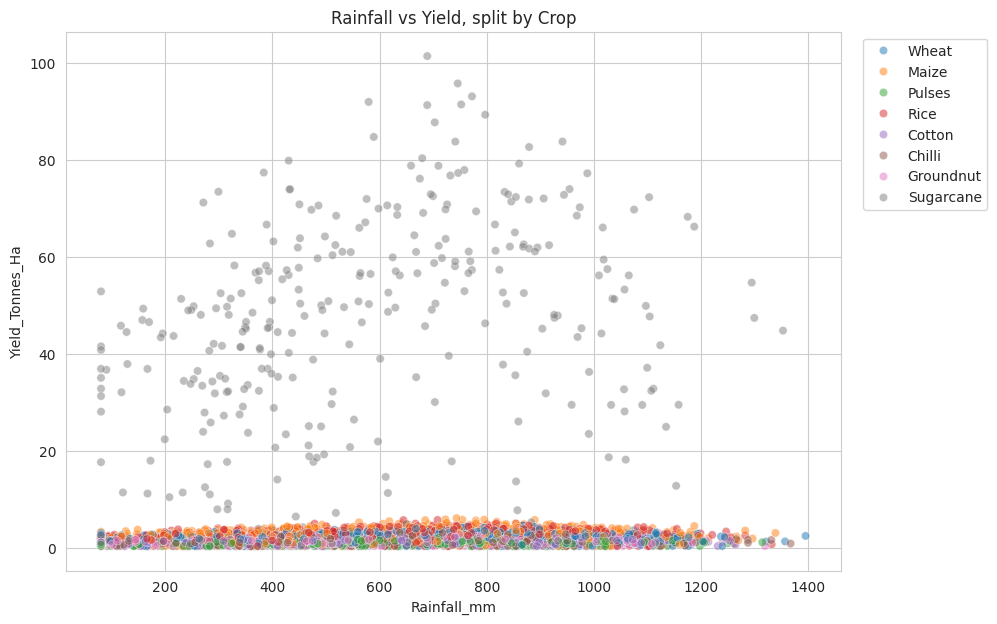

In [29]:
plt.figure(figsize=(10,7))
sns.scatterplot(data=df, x='Rainfall_mm', y='Yield_Tonnes_Ha', hue='Crop', alpha=0.5)
plt.title('Rainfall vs Yield, split by Crop')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.show()


Once colour-coded by crop, the picture makes more sense - sugarcane sits in its own band up top regardless of rainfall, while the other crops cluster lower down. So crop type is doing more work than rainfall alone in explaining the earlier flat-looking scatter.

In [30]:
pivot = df.pivot_table(values='Profit_INR', index='Crop', columns='Season', aggfunc='mean')
pivot.round(0)


Season,Kharif,Rabi,Zaid
Crop,,,
Chilli,954380.0,638572.0,448659.0
Cotton,217000.0,107344.0,-53925.0
Groundnut,108265.0,10417.0,-68872.0
Maize,-39333.0,-89133.0,-194049.0
Pulses,43339.0,-14309.0,-139228.0
Rice,-64903.0,-98428.0,-227239.0
Sugarcane,1000791.0,731613.0,583636.0
Wheat,-105872.0,-119955.0,-193209.0


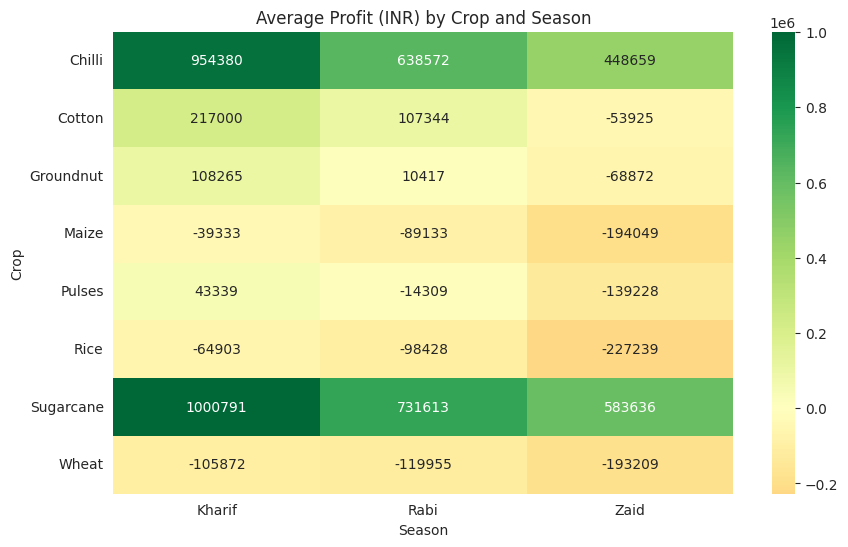

In [31]:
plt.figure(figsize=(10,6))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='RdYlGn', center=0)
plt.title('Average Profit (INR) by Crop and Season')
plt.show()


This heatmap is one of the more useful views in the whole notebook - Sugarcane and Chilli stay in the green (profitable) across every season, while Wheat and Rice are red almost everywhere, meaning the loss isn't tied to a bad season, it's closer to a structural issue with those crops in this dataset.

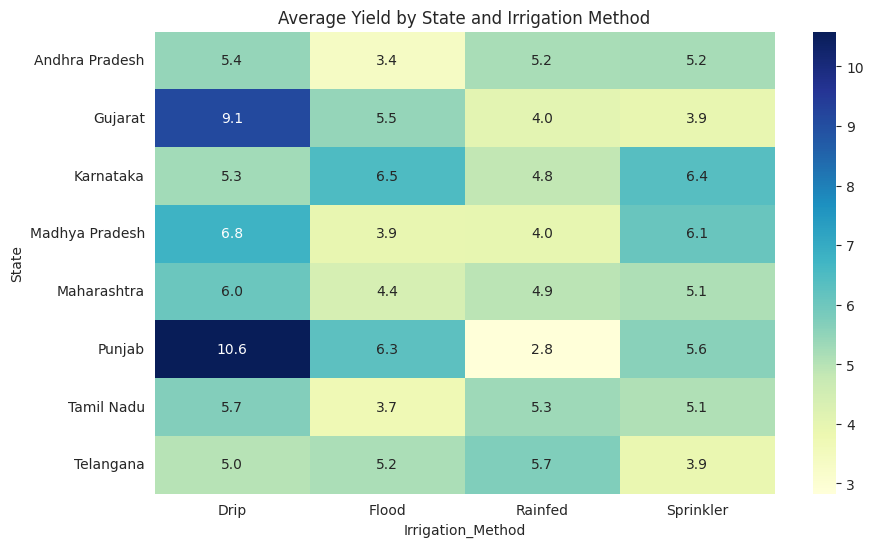

In [32]:
grouped = df.groupby(['State', 'Irrigation_Method'])['Yield_Tonnes_Ha'].mean().unstack()
plt.figure(figsize=(10,6))
sns.heatmap(grouped, annot=True, fmt='.1f', cmap='YlGnBu')
plt.title('Average Yield by State and Irrigation Method')
plt.show()


## 10. Correlation analysis

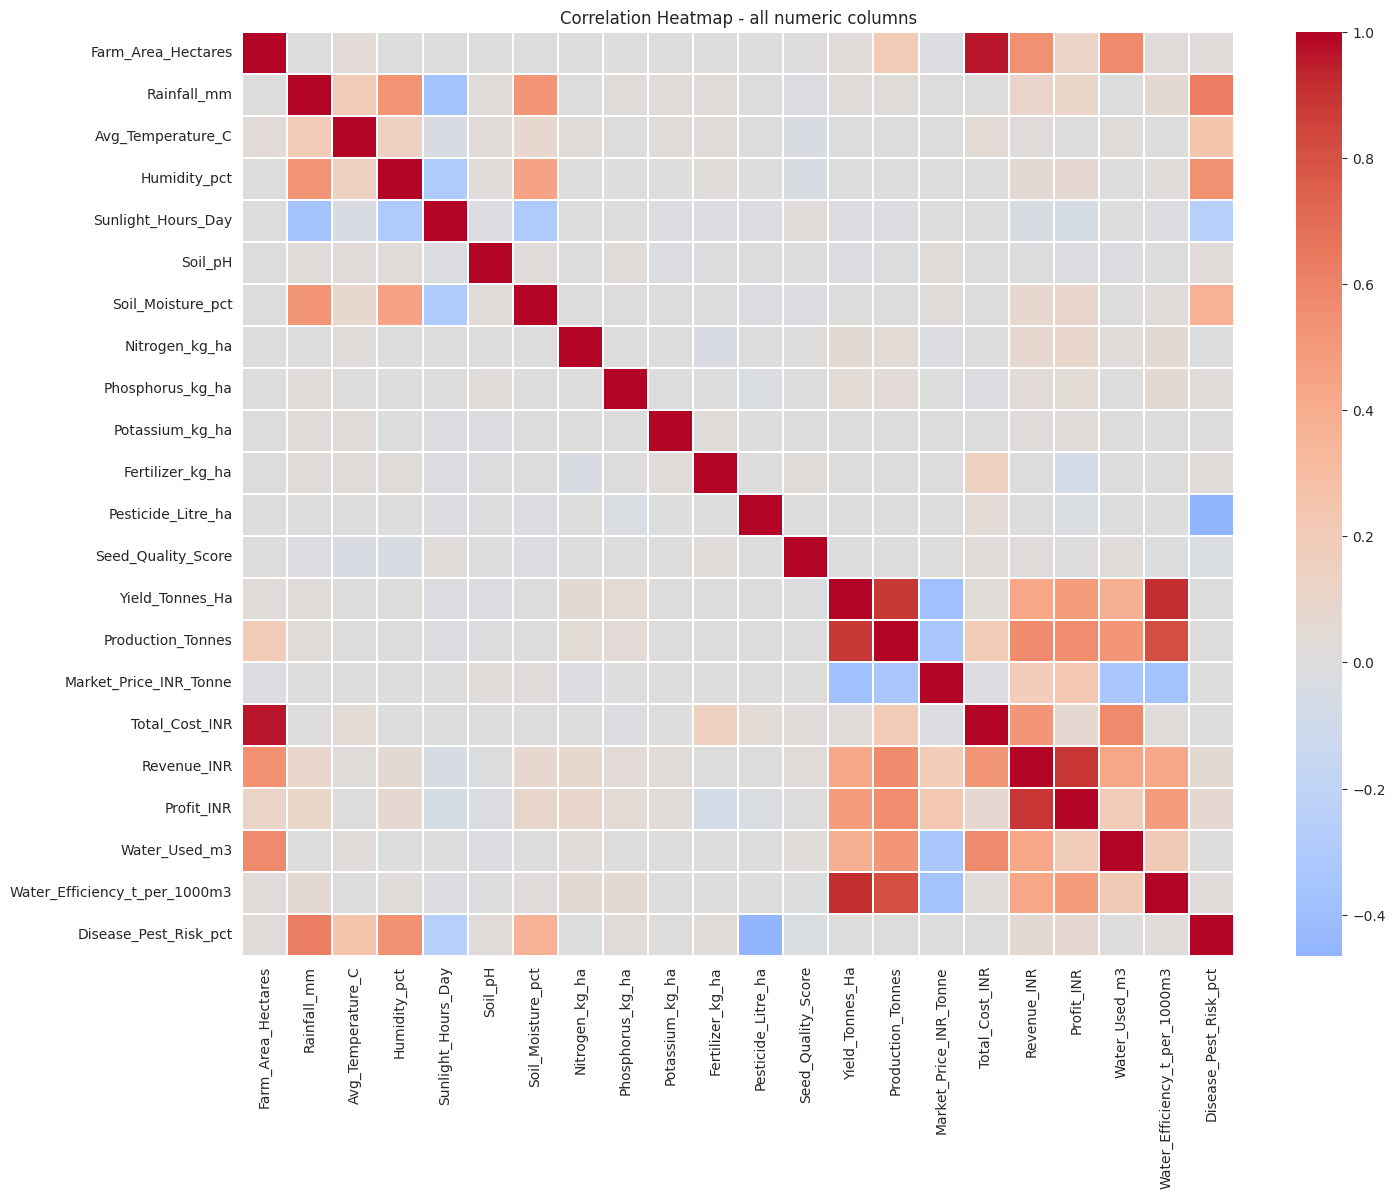

In [33]:
corr = df[num_cols].corr()
plt.figure(figsize=(16,12))
sns.heatmap(corr, annot=False, cmap='coolwarm', center=0, linewidths=0.3)
plt.title('Correlation Heatmap - all numeric columns')
plt.show()


In [34]:
corr['Profit_INR'].sort_values(ascending=False)


Profit_INR                       1.000000
Revenue_INR                      0.887331
Production_Tonnes                0.554172
Water_Efficiency_t_per_1000m3    0.489487
Yield_Tonnes_Ha                  0.489328
Market_Price_INR_Tonne           0.225119
Water_Used_m3                    0.190278
Farm_Area_Hectares               0.115241
Rainfall_mm                      0.106117
Soil_Moisture_pct                0.091281
Nitrogen_kg_ha                   0.085016
Total_Cost_INR                   0.068356
Disease_Pest_Risk_pct            0.067583
Humidity_pct                     0.063775
Phosphorus_kg_ha                 0.049747
Potassium_kg_ha                  0.031192
Seed_Quality_Score               0.010438
Avg_Temperature_C                0.009043
Soil_pH                         -0.013145
Pesticide_Litre_ha              -0.025705
Sunlight_Hours_Day              -0.054822
Fertilizer_kg_ha                -0.073542
Name: Profit_INR, dtype: float64

Profit correlates most strongly with `Revenue_INR` (0.89, expected since profit is derived from revenue), then `Production_Tonnes` (0.55) and `Yield_Tonnes_Ha` (0.49). What's more telling is the weak end of the list - `Total_Cost_INR` only correlates at 0.07 with profit and input-heavy columns like `Fertilizer_kg_ha`, `Pesticide_Litre_ha`, `Nitrogen_kg_ha` are all close to zero or even slightly negative. So spending more on inputs is not, by itself, linked to more profit in this data.

In [35]:
corr['Yield_Tonnes_Ha'].sort_values(ascending=False)


Yield_Tonnes_Ha                  1.000000
Water_Efficiency_t_per_1000m3    0.915534
Production_Tonnes                0.885447
Profit_INR                       0.489328
Revenue_INR                      0.433025
Water_Used_m3                    0.387338
Nitrogen_kg_ha                   0.053616
Phosphorus_kg_ha                 0.046554
Total_Cost_INR                   0.030915
Farm_Area_Hectares               0.030569
Rainfall_mm                      0.026837
Disease_Pest_Risk_pct            0.012286
Humidity_pct                     0.010507
Soil_Moisture_pct                0.010072
Avg_Temperature_C                0.009085
Potassium_kg_ha                  0.005249
Fertilizer_kg_ha                -0.000417
Seed_Quality_Score              -0.007767
Pesticide_Litre_ha              -0.008620
Sunlight_Hours_Day              -0.015438
Soil_pH                         -0.021797
Market_Price_INR_Tonne          -0.384259
Name: Yield_Tonnes_Ha, dtype: float64

Interesting one here - `Market_Price_INR_Tonne` has a -0.38 correlation with yield. At first that looks backwards (shouldn't higher yield crops make more money per tonne, or at least not less?), but it's the crop mix causing it: Sugarcane has huge yield but a low per-tonne price, while Chilli has low yield but a high per-tonne price. So this correlation is really describing crop economics, not a real cause-and-effect between yield and price within a single crop.

## 11. Seasonal comparisons

In [36]:
season_summary = df.groupby('Season').agg(
    avg_yield=('Yield_Tonnes_Ha', 'mean'),
    avg_profit=('Profit_INR', 'mean'),
    avg_rainfall=('Rainfall_mm', 'mean'),
    avg_temp=('Avg_Temperature_C', 'mean'),
    loss_making_pct=('Profit_INR', lambda x: (x < 0).mean() * 100)
).round(2)
season_summary


,avg_yield,avg_profit,avg_rainfall,avg_temp,loss_making_pct
Season,,,,,
Kharif,5.63,178914.65,852.11,28.45,42.21
Rabi,5.10,87689.47,435.94,23.49,51.14
Zaid,4.64,-24804.82,299.12,31.04,64.48


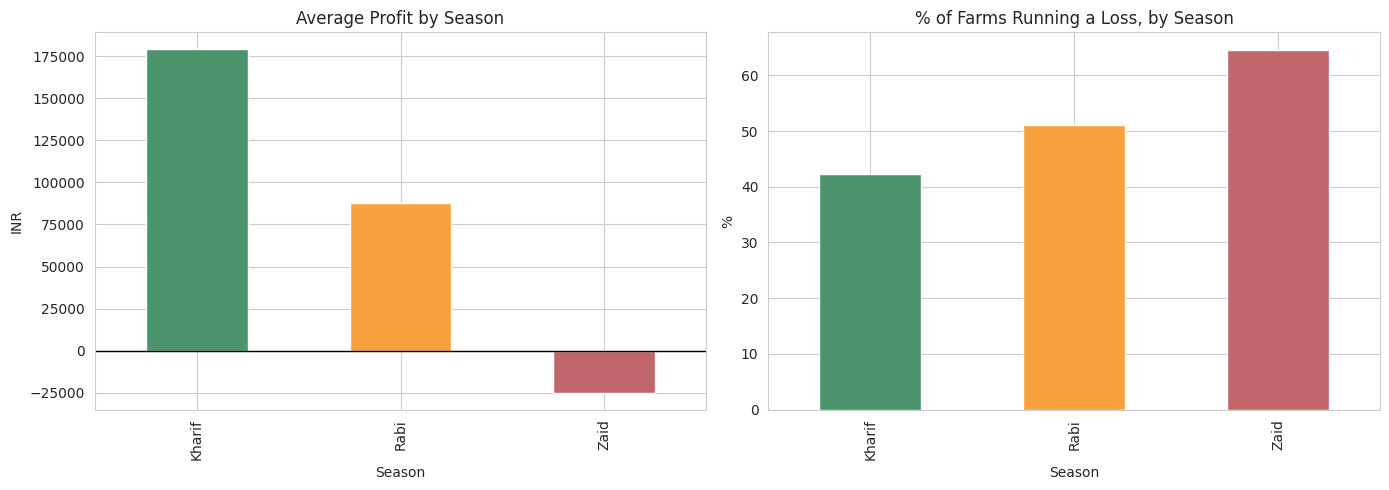

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

season_summary['avg_profit'].plot(kind='bar', ax=axes[0], color=['#4C956C','#F9A03F','#C1666B'])
axes[0].axhline(0, color='black', linewidth=1)
axes[0].set_title('Average Profit by Season')
axes[0].set_ylabel('INR')

season_summary['loss_making_pct'].plot(kind='bar', ax=axes[1], color=['#4C956C','#F9A03F','#C1666B'])
axes[1].set_title('% of Farms Running a Loss, by Season')
axes[1].set_ylabel('%')

plt.tight_layout()
plt.show()


Kharif comes out ahead on both counts - highest average profit and the lowest share of loss-making farms. Zaid is the weakest season by a clear margin, with close to (or above) half its farms running a loss. This tracks with the rainfall numbers too - Zaid is the driest season on average and low rainfall combined with high summer heat is a rough combination for most crops here.

In [38]:
crop_season = df.groupby(['Crop', 'Season'])['Yield_Tonnes_Ha'].mean().unstack().round(2)
crop_season


Season,Kharif,Rabi,Zaid
Crop,,,
Chilli,1.73,1.46,1.19
Cotton,1.37,1.19,0.95
Groundnut,1.48,1.23,1.04
Maize,2.97,2.62,2.30
Pulses,1.04,0.87,0.66
Rice,2.71,2.34,1.90
Sugarcane,53.46,44.00,38.42
Wheat,2.26,2.06,1.75


Wheat and Pulses are grown as Rabi crops mostly and Rice, Maize, Cotton lean Kharif - worth remembering that season and crop aren't independent of each other in this dataset, farmers naturally pick a season that suits the crop, so some of the seasonal pattern is really a crop pattern in disguise.

## 12. Student-designed analysis

Three questions I came up with myself while poking around the data, that weren't part of the standard checklist above.

### 12.1 - Does farm size actually help profit? ("economies of scale" check)

Bigger farms should, in theory, have some cost advantages. Wanted to check if that shows up here at all.

In [39]:
df['Area_Bracket'] = pd.cut(df['Farm_Area_Hectares'], bins=[0,3,6,9,12,15],
                            labels=['0-3', '3-6', '6-9', '9-12', '12-15'])

area_summary = df.groupby('Area_Bracket').agg(
    avg_profit=('Profit_INR', 'mean'),
    avg_profit_per_ha=('Profit_INR', 'mean'),
    n=('Farm_ID', 'count')
)
# profit per hectare needs the actual area, not just grouped mean of profit
df['Profit_per_Ha'] = df['Profit_INR'] / df['Farm_Area_Hectares']
area_summary['avg_profit_per_ha'] = df.groupby('Area_Bracket')['Profit_per_Ha'].mean()
area_summary.round(0)


,avg_profit,avg_profit_per_ha,n
Area_Bracket,,,
0-3,20045.0,11560.0,669
3-6,53867.0,11806.0,829
6-9,112891.0,14805.0,796
9-12,170817.0,16193.0,817
12-15,178561.0,13144.0,889


/tmp/ipykernel_475/3031394487.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Area_Bracket', y='Profit_per_Ha', palette='crest', errorbar=None)


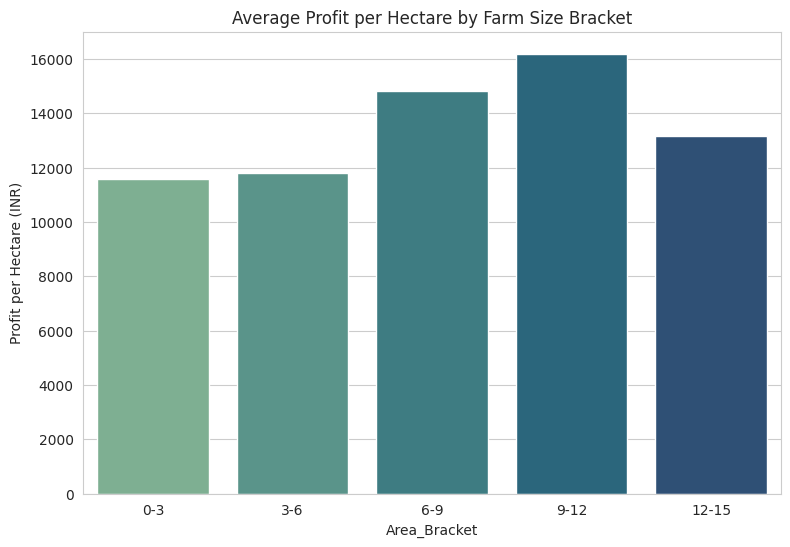

In [40]:
plt.figure(figsize=(9,6))
sns.barplot(data=df, x='Area_Bracket', y='Profit_per_Ha', palette='crest', errorbar=None)
plt.title('Average Profit per Hectare by Farm Size Bracket')
plt.ylabel('Profit per Hectare (INR)')
plt.show()


Doesn't look like bigger farms are doing meaningfully better per hectare - the brackets are fairly close to each other, no clean upward or downward trend. So in this dataset, farm size on its own isn't a strong driver of profitability - what crop you grow and what season you're in seem to matter a lot more (as seen earlier).

### 12.2 - Is there a "sweet spot" for disease/pest risk vs yield?

The dataset has a `Disease_Pest_Risk_pct` column. Wanted to see if high risk actually translates into lower yield, or if it's more noise than signal.

In [41]:
df['Risk_Bracket'] = pd.cut(df['Disease_Pest_Risk_pct'], bins=[0,20,40,60,80,100],
                            labels=['0-20', '20-40', '40-60', '60-80', '80-100'])

risk_summary = df.groupby('Risk_Bracket')['Yield_Tonnes_Ha'].agg(['mean','median','count'])
risk_summary.round(2)


,mean,median,count
Risk_Bracket,,,
0-20,3.72,1.49,63
20-40,5.23,1.61,1196
40-60,5.38,1.80,2180
60-80,4.96,1.75,549
80-100,11.29,2.26,12


/tmp/ipykernel_475/490832649.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Risk_Bracket', y='Yield_Tonnes_Ha', palette='flare')


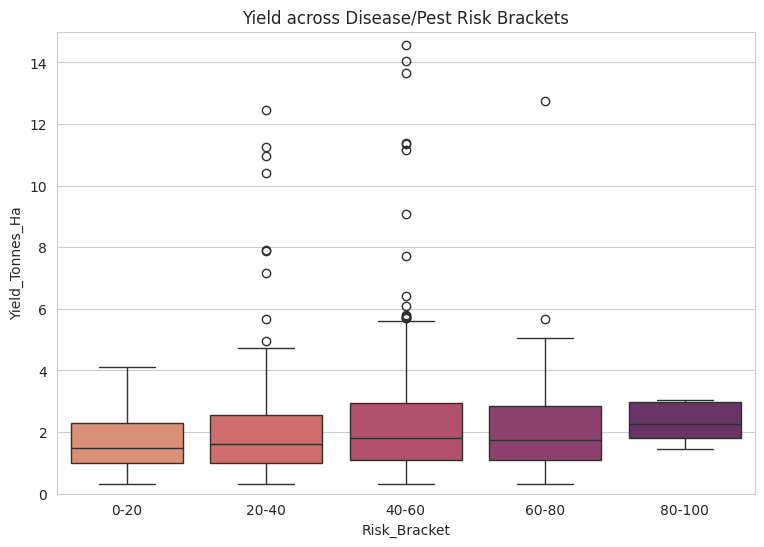

In [42]:
plt.figure(figsize=(9,6))
sns.boxplot(data=df, x='Risk_Bracket', y='Yield_Tonnes_Ha', palette='flare')
plt.title('Yield across Disease/Pest Risk Brackets')
plt.ylim(0, 15)  # cutting off the sugarcane tail just for this plot so the boxes are readable
plt.show()


The medians barely move across risk brackets. Either the pest/disease risk score in this dataset isn't strongly tied to actual yield loss, or something else (irrigation, crop type) is masking the effect. Worth flagging as a question for whoever owns this dataset rather than a conclusion I'd bet money on.

### 12.3 - Which state + crop + irrigation combo actually works best?

Instead of looking at these three factors separately, wanted to find the specific combinations that are consistently profitable, since a farmer reading this would care about their own state, not the national average.

In [43]:
combo = df.groupby(['State', 'Crop', 'Irrigation_Method']).agg(
    avg_profit=('Profit_INR', 'mean'),
    n=('Farm_ID', 'count')
).reset_index()

# only keeping combos with a decent number of records so we're not drawing conclusions from 2 farms
combo_reliable = combo[combo['n'] >= 15].sort_values('avg_profit', ascending=False)
combo_reliable.head(10)


,State,Crop,Irrigation_Method,avg_profit,n
56,Gujarat,Sugarcane,Drip,1.409636e+06,15
161,Punjab,Chilli,Flood,1.162920e+06,18
192,Tamil Nadu,Chilli,Drip,1.139191e+06,15
184,Punjab,Sugarcane,Drip,9.028417e+05,18
129,Maharashtra,Chilli,Flood,8.929385e+05,18
33,Gujarat,Chilli,Flood,8.753501e+05,17
128,Maharashtra,Chilli,Drip,8.605981e+05,17
89,Karnataka,Sugarcane,Flood,8.013002e+05,18
65,Karnataka,Chilli,Flood,7.213064e+05,17
2,Andhra Pradesh,Chilli,Rainfed,7.099431e+05,18


In [44]:
combo_reliable.tail(10)

,State,Crop,Irrigation_Method,avg_profit,n
190,Punjab,Wheat,Rainfed,-159318.666667,18
126,Madhya Pradesh,Wheat,Rainfed,-167706.086957,23
181,Punjab,Rice,Flood,-170340.440000,25
149,Maharashtra,Rice,Flood,-177232.870968,31
44,Gujarat,Maize,Drip,-180621.666667,21
29,Andhra Pradesh,Wheat,Flood,-192839.166667,30
213,Tamil Nadu,Rice,Flood,-193930.757576,33
31,Andhra Pradesh,Wheat,Sprinkler,-200496.000000,17
189,Punjab,Wheat,Flood,-214639.000000,22
85,Karnataka,Rice,Flood,-241880.888889,27


Top of the list is dominated by Sugarcane and Chilli combinations across a handful of states, using Drip or Sprinkler irrigation. Bottom of the list is Wheat and Rice, mostly under Flood or Rainfed irrigation. This lines up with everything found earlier, but now it's specific enough that someone could actually act on it (e.g. "if you're in Maharashtra growing Chilli, drip irrigation shows up in the better-performing group").

## 13. Key insights

Pulling together the findings from the sections above into standalone points.

1. **Almost half of all farm records (49%) show a net loss.** This isn't a small-sample fluke - it's spread across the dataset, so profitability is a genuine problem here, not an edge case.
2. **Crop choice matters more than almost anything else measured.** Sugarcane and Chilli average strong positive profits in every season, while Wheat and Rice average a loss in every season. That's a structural gap, not a bad-year problem.
3. **Kharif is the strongest season, Zaid is the weakest.** Kharif has the highest average profit and lowest share of loss-making farms; Zaid has the lowest rainfall on average and the highest share of farms in the red.
4. **Fertilizer, Nitrogen and Pesticide use show almost no correlation with yield or profit** (all under 0.09 in absolute value). More input spend doesn't appear to be buying more output in this dataset - which either means input use is already at a point of diminishing returns, or the extra input isn't being used efficiently.
5. **Rainfed irrigation shows the highest "water efficiency" number, but this is likely a measurement artifact rather than genuinely better irrigation** - rainfed plots probably aren't fully counting natural rainfall as "water used," which would inflate the ratio. Worth treating this metric carefully rather than concluding rainfed is the best method.
6. **The apparent 302 "yield outliers" are not data errors - they are almost entirely Sugarcane records.** Sugarcane yields 15-30x more per hectare than most other crops by nature, so a flat outlier check across the whole dataset misclassifies an entire crop as anomalous.
7. **Yield and Market Price move in opposite directions (-0.38 correlation), but this is a crop-mix effect, not a real economic law.** High-yield crops (sugarcane) happen to have low per-tonne prices and low-yield crops (chilli) happen to have high per-tonne prices in this data.
8. **Farm size doesn't show a clear relationship with profit per hectare.** Bracketing farms from small to large, profit-per-hectare stays roughly flat - bigger isn't obviously better here, at least not on its own.
9. **Disease/Pest risk score doesn't show a clean relationship with yield either**, based on the bracket comparison - median yield barely shifts even at the highest risk bracket, which is a bit counterintuitive and worth a second look with better data.
10. **Specific state + crop + irrigation combinations show much bigger profit gaps than any single factor alone** - e.g. Chilli/Sugarcane with Drip or Sprinkler irrigation clusters at the top, Wheat/Rice with Flood or Rainfed clusters at the bottom.


## 14. Recommendations

Based only on the patterns actually observed in this dataset (not general farming advice from outside it):

- **Re-examine Wheat and Rice economics before recommending them further** - both run an average loss across every season and state combination checked. Either the cost side (fertilizer, pesticide, water) needs to come down, or the selling price/market channel needs improvement, because right now the yield side alone won't fix the loss.
- **Shift more of the loss-making Zaid-season acreage toward Kharif where feasible**, or pick more drought-tolerant crop choices for Zaid specifically - the profit gap between these two seasons is large and rainfall looks like a big part of the reason.
- **Don't assume more fertilizer/pesticide automatically means more yield** - the data doesn't support that here. Worth running an actual controlled comparison (same crop, same season, varying only input levels) before recommending increased input spend to farmers.
- **Treat the "Rainfed = most water efficient" result with caution** and check how water use is actually being measured for rainfed plots before using this to promote rainfed irrigation - it may be an artifact of not counting rainwater the same way as pumped water.
- **Use the combined state + crop + irrigation view (section 12.3), not single-factor averages, when advising an individual farmer** - a general "Kharif is best" or "Drip is best" statement hides a lot of variation that only shows up once you look at the specific combination relevant to that farmer.


## 15. Limitations

- This is cross-sectional data (each row looks like one farm-season record) - there's no repeated observation of the *same* farm over multiple years, so it's not possible to say whether a given farm's profit is a one-off bad season or a persistent pattern.
- Season and crop are not independent (Wheat/Pulses lean Rabi, Rice/Maize/Cotton lean Kharif), so some of what looks like a "seasonal effect" could partly be a "crop effect" wearing a season's clothing and this notebook can't fully separate the two with the columns available.
- No causal claims can be made from correlation alone - e.g. the near-zero fertilizer/yield correlation doesn't prove fertilizer doesn't help, only that within this specific dataset, more fertilizer use isn't tracking with more yield.
- `Water_Used_m3` for rainfed plots may not be measured on the same basis as pumped irrigation methods, which would bias the water efficiency comparison in section 8 (flagged above too).
- The dataset only covers 8 states and 8 crops, so none of this should be generalized to crops or regions outside what's actually in the data.
- Missing values were filled using group medians (by crop or season) rather than dropped, which keeps the row count intact but does slightly soften the true variance of those columns.


## 16. Conclusion

Season and crop choice turned out to matter a lot more than input spend in this dataset. Kharif-season farms and Sugarcane/Chilli growers are consistently on the profitable side, while Zaid-season farms and Wheat/Rice growers are consistently on the losing side and that gap holds up across states and irrigation methods rather than being a one-off. Meanwhile, heavier fertilizer and pesticide use didn't show any real link to better yield or profit, which was probably the most unexpected finding in the whole exercise.

None of this is meant as a final answer - it's a first pass that flags where the real questions are (crop economics, Zaid-season risk, the rainfed water-efficiency number and the input-spend puzzle) and each of those would be worth digging into with more targeted data before acting on them.
